<a href="https://colab.research.google.com/github/V-Lozovoy/deep-learn/blob/main/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-14-bfd3556936b9>:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


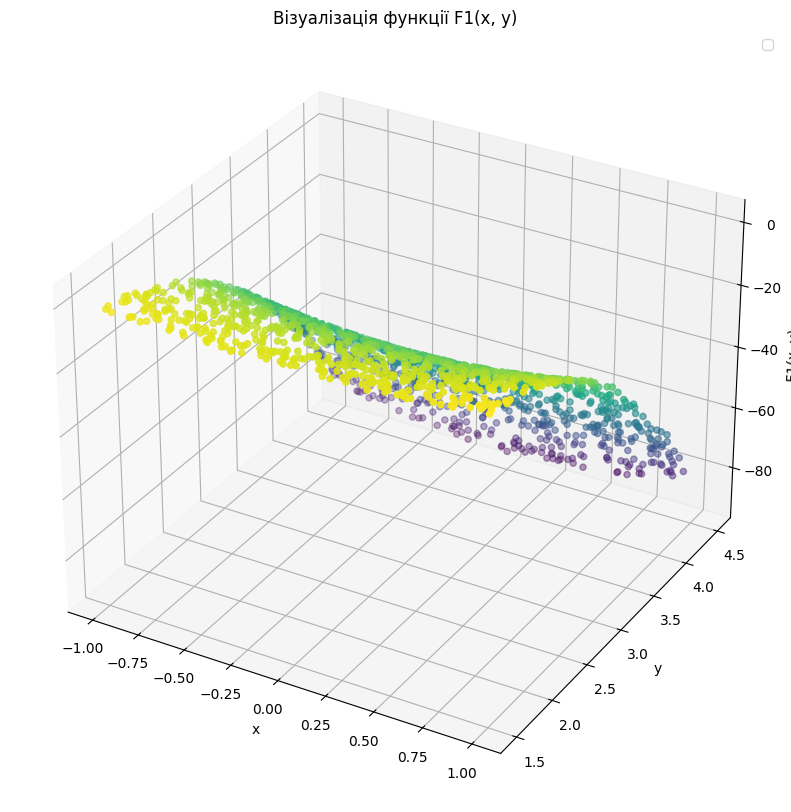

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1669.9742 - val_loss: 1362.9341
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1488.1630 - val_loss: 1134.9207
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1195.7803 - val_loss: 709.0898
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 629.1285 - val_loss: 260.4259
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 184.9164 - val_loss: 70.7784
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.5262 - val_loss: 28.1463
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.9312 - val_loss: 18.7460
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.4232 - val_loss: 15.0033
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.6802 - val_loss: 12.4400
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.8922 - val_loss: 10.3658
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.9292 - val_loss: 8.8368
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Input
from tensorflow.keras.utils import plot_model


# Завантаження даних
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/tensorflow_dataset.csv')

# Вхідні та цільові дані
X = data[['x', 'y']].values
y = data['F1(x, y)'].values

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['x'], data['y'], data['F1(x, y)'], c=data['F1(x, y)'], cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('F1(x, y)')
plt.title("Візуалізація функції F1(x, y)")
plt.legend()
plt.show()

# Розділення на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. DENSE MODEL ---
dense_model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(64, activation='relu'),
    Dense(1)  # Регресія → без активації
])

dense_model.compile(optimizer='adam', loss='mse')
dense_model.summary()

# Навчання DENSE
dense_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1)


# Модель CNN
# Перетворення даних під CNN: (samples, height=1, width=2, channels=1)
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], 2, 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], 2, 1))

cnn_model = Sequential([
    Conv1D(32, kernel_size=1, activation='relu', input_shape=(2, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

# Навчання CNN
cnn_model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_split=0.1)

# Оцінка моделей
y_prediction_dense = dense_model.predict(X_test_scaled)
y_prediction_cnn = cnn_model.predict(X_test_cnn)

mse_dense = mean_squared_error(y_test, y_prediction_dense)
mse_cnn = mean_squared_error(y_test, y_prediction_cnn)

print(f"Похибка для моделі Dense: {mse_dense}")
print(f"Похибка для моделі CNN: {mse_cnn}")

# Перші 200 точок
x_plot = X_test_scaled[:200]
x_200 = x_plot[:, 0]
y_200 = x_plot[:, 1]
z_true = y_test[:200]
z_prediction = y_prediction_dense[:200].flatten()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Справжні значення
ax.scatter(x_200, y_200, z_true, c='blue', label='Справжні', alpha=0.6)

# Прогнозовані значення
ax.scatter(x_200, y_200, z_prediction, c='red', label='Прогнозовані', alpha=0.6)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('F1(x, y)')
ax.set_title('Порівняння справжніх та прогнозованих значень функції F1(x, y)')
ax.legend()
plt.show()